<a href="https://colab.research.google.com/github/simomorphine/probabilistic_decision_tree/blob/main/elwardi_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Elwardi Algorithms
## DecisionTreeBandit — Benchmark & Presentation

> *Author: Mohamed Elwardi*  
> *Part of the Humble Systems Theory framework*


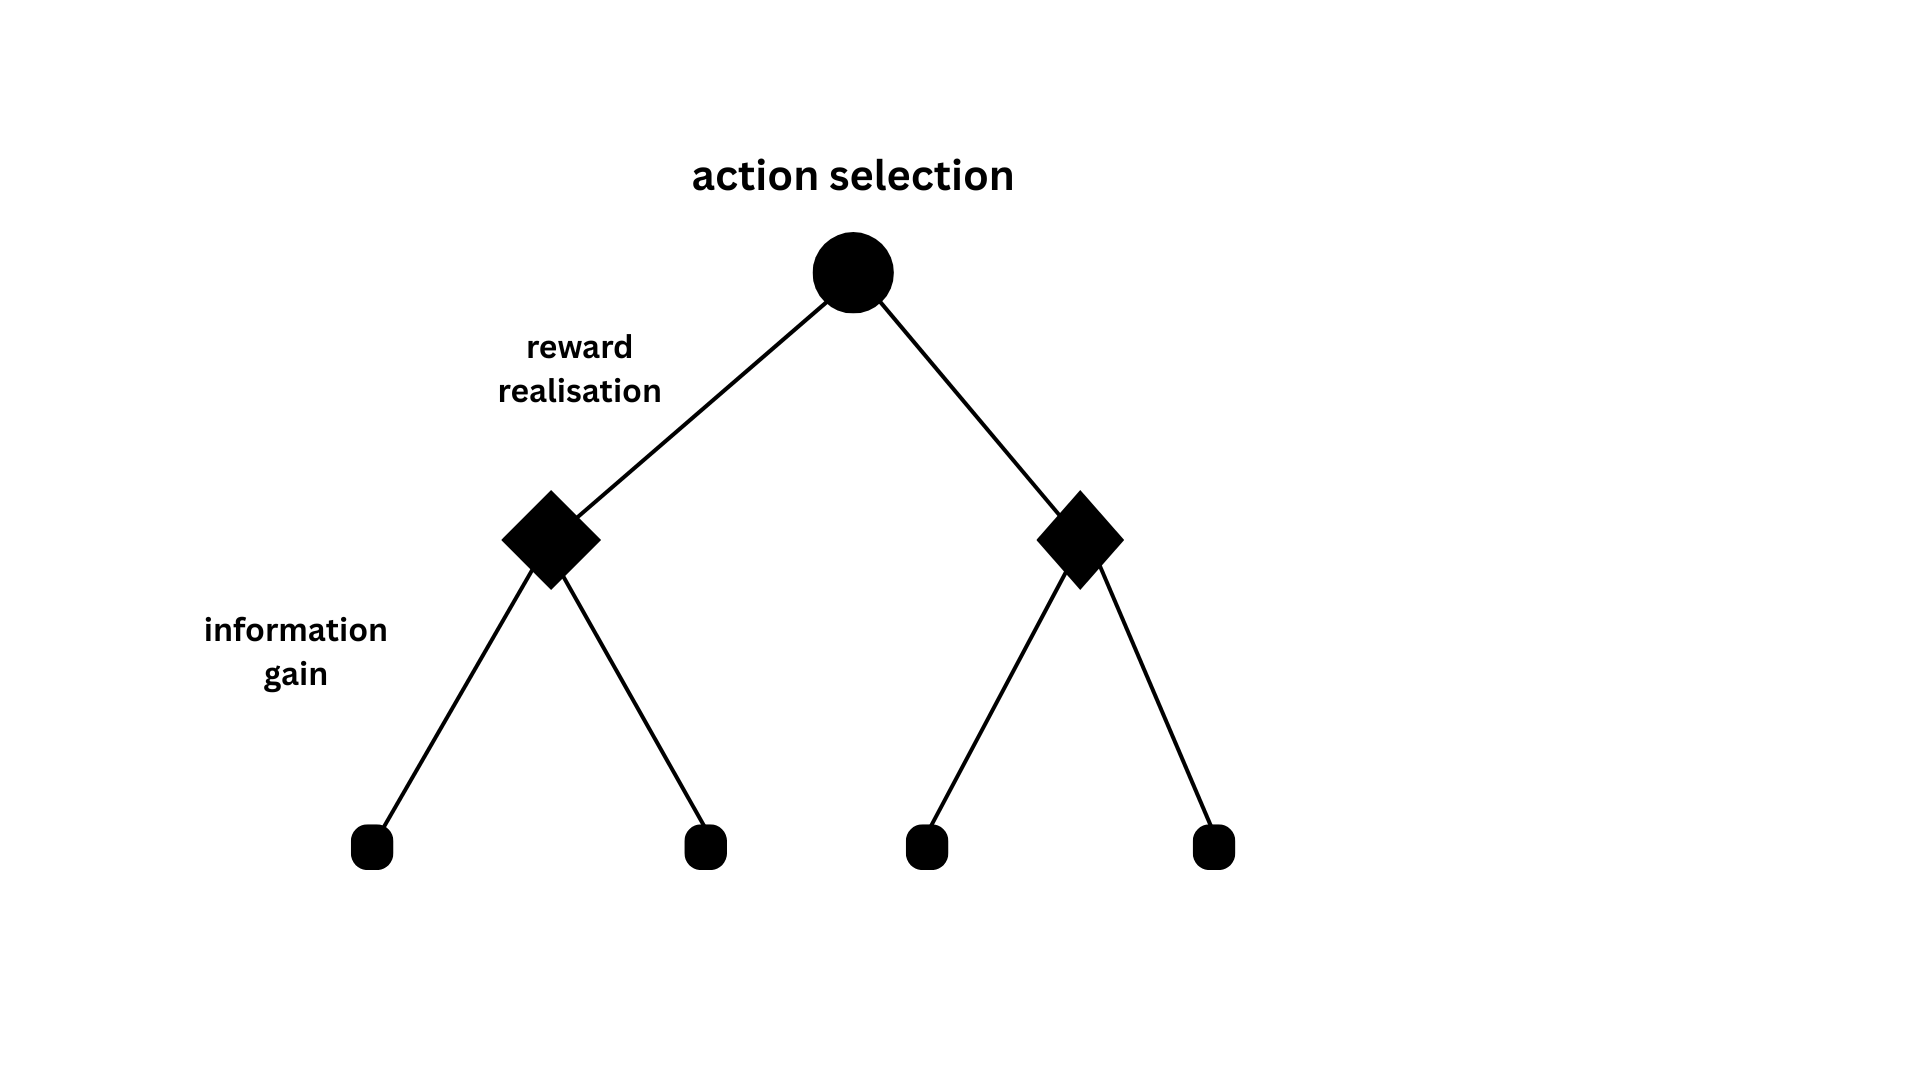

# 1. The Probabilistic Decision Tree

## 1.1 Basic Setup

Consider an agent operating in an unknown environment characterized by parameters $\theta \in \Theta$. At time $t$, the agent must choose an action $a \in \mathcal{A}$.

We model the decision process as a **three-level probabilistic tree**.

---

### Level 1: Action Selection

The agent maintains a current policy $\pi_{\text{current}}$, but may deviate with exploration probability $1 - \alpha$:

$$A \sim \begin{cases} \pi_{\text{current}} & \text{w.p. } \alpha \\ \pi_{\text{explore}} & \text{w.p. } 1-\alpha \end{cases}$$

For simplicity, we denote:

- $A = P$ (policy / exploit) with probability $\alpha$
- $A = E$ (explore) with probability $1 - \alpha$

---

### Level 2: Reward Realization

Conditioned on action $a$ and environment parameters $\theta$, the agent receives reward:

$$R \mid A=a,\, \theta \sim p_{\theta}(\cdot \mid a)$$

For analytical tractability, consider binary rewards $R \in \{+r, -r\}$:

$$P(R = +r \mid A=a, \theta) = p_a(\theta)$$

---

### Level 3: Information Gain

Crucially, **observing a reward does not guarantee learning**. We model information gain as a binary event:

$$I \in \{0, 1\}$$

where:
- $I = 1$ indicates the experience was **informative** (reduced uncertainty about $\theta$)
- $I = 0$ indicates it was **uninformative** (noisy, ambiguous, or redundant)

The probability of information gain depends on both action and reward:

$$P(I=1 \mid A=a, R=r, \theta) = q_{a,r}(\theta)$$

This captures three important phenomena:

| Phenomenon | Condition | Meaning |
|---|---|---|
| **Informative failures** | $q_{a,-r}$ high | Negative reward but high information |
| **Uninformative successes** | $q_{a,+r}$ low | Positive reward but low information |
| **Exploration bias** | $q_{E,r} > q_{P,r}$ | Exploration is more informative than exploitation |

---

## 1.2 Joint Probability Distribution

The complete tree defines a joint distribution:

$$P(A, R, I \mid \theta) = P(A) \cdot P(R \mid A, \theta) \cdot P(I \mid A, R, \theta)$$

Explicitly:

$$P(A=a, R=r, I=i \mid \theta) = \mathbb{1}[A=a] \cdot p_a^{(r)}(\theta) \cdot q_{a,r}^{(i)}(\theta)$$

where:

- $\mathbb{1}[A=a] \in \{\alpha, 1-\alpha\}$ is the action probability
- $p_a^{(+r)}(\theta) = p_a(\theta)$ and $p_a^{(-r)}(\theta) = 1 - p_a(\theta)$
- $q_{a,r}^{(1)}(\theta) = q_{a,r}(\theta)$ and $q_{a,r}^{(0)}(\theta) = 1 - q_{a,r}(\theta)$

> **The joint distribution $P(A, R, I \mid \theta)$ is the decision tree.**

### Theoretical Foundation

The algorithm derives from a decision-theoretic utility framework:

$$E[U|a] = \underbrace{\mu(a)}_{\text{exploit}} + \lambda \cdot \underbrace{\frac{1}{1 + \text{pulls}(a)}}_{\text{information value}}$$

Exploration is not a heuristic add-on — it emerges from **rational utility maximization under uncertainty**.

**Three belief variants:**
| Belief | Environment | Mechanism |
|---|---|---|
| `StandardBelief` | Stationary | Full history |
| `DiscountedBelief` | Non-stationary, gradual drift | Exponential forgetting |
| `SurpriseBelief` | Non-stationary, abrupt shifts | Adaptive surprise gate |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import beta as beta_dist

plt.rcParams.update({
    'figure.facecolor' : '#0f0f0f',
    'axes.facecolor'   : '#1a1a1a',
    'axes.edgecolor'   : '#333333',
    'axes.labelcolor'  : '#cccccc',
    'xtick.color'      : '#888888',
    'ytick.color'      : '#888888',
    'text.color'       : '#cccccc',
    'grid.color'       : '#2a2a2a',
    'grid.linestyle'   : '-',
    'axes.grid'        : True,
    'legend.facecolor' : '#1a1a1a',
    'legend.edgecolor' : '#333333',
    'font.size'        : 11,
})

COLORS = {
    'elwardi'   : '#00d4aa',
    'thompson'  : '#f97316',
    'ucb1'      : '#6366f1',
    'klucb'     : '#ec4899',
    'standard'  : '#9ca3af',
    'disc_095'  : '#00d4aa',
    'disc_099'  : '#7c3aed',
    'sliding'   : '#f97316',
    'shift'     : '#ffffff',
}

print('Setup complete.')

Setup complete.


---
## 1. The Algorithm

In [2]:
# ── Beliefs ──────────────────────────────────────────────────
class StandardBelief:
    """Beta(α,β) — weights all past observations equally."""
    def __init__(self):
        self.alpha = 1.0
        self.beta  = 1.0

    def mean(self):            return self.alpha / (self.alpha + self.beta)
    def sample(self):          return np.random.beta(self.alpha, self.beta)
    def effective_pulls(self): return self.alpha + self.beta - 2

    def update(self, reward):
        self.alpha += reward
        self.beta  += (1 - reward)


class DiscountedBelief:
    """Exponentially weighted Beta — forgets the past at rate γ.
    Effective memory ≈ 1/(1-γ) steps.
    """
    def __init__(self, gamma=0.95):
        self.alpha = 1.0
        self.beta  = 1.0
        self.gamma = gamma

    def mean(self):            return self.alpha / (self.alpha + self.beta)
    def sample(self):          return np.random.beta(max(self.alpha, 0.01), max(self.beta, 0.01))
    def effective_pulls(self): return self.alpha + self.beta - 2

    def update(self, reward):
        self.alpha = self.gamma * self.alpha + reward
        self.beta  = self.gamma * self.beta  + (1 - reward)


class SurpriseBelief:
    """Adaptive learning rate via surprise gate.
    gate = max(q, running_surprise)
    Opens when environment shifts — detected through prediction error.
    """
    def __init__(self, beta=0.7):
        self.alpha            = 1.0
        self.beta_param       = 1.0
        self.beta             = beta
        self.running_surprise = 0.0

    def mean(self):            return self.alpha / (self.alpha + self.beta_param)
    def sample(self):          return np.random.beta(max(self.alpha, 0.01), max(self.beta_param, 0.01))
    def effective_pulls(self): return self.alpha + self.beta_param - 2

    def update(self, reward):
        surprise              = abs(reward - self.mean())
        self.running_surprise = self.beta * self.running_surprise + (1 - self.beta) * surprise
        q                     = 1.0 / (1.0 + self.effective_pulls())
        gate                  = max(q, self.running_surprise)
        self.alpha            += reward       * gate
        self.beta_param       += (1 - reward) * gate


# ── Agent ─────────────────────────────────────────────────────

class DecisionTreeBandit:
    """
    E[U|a] = mean(a) + λ * q(a)
    q(a)   = 1 / (1 + effective_pulls(a))
    arm    = argmax E[U|a]
    """
    def __init__(self, n_arms, belief_cls, belief_kw=None, lambda_val=0.5):
        self.lambda_val = lambda_val
        kw = belief_kw or {}
        self.beliefs = [belief_cls(**kw) for _ in range(n_arms)]

    def select_arm(self):
        eu = [b.mean() + self.lambda_val / (1.0 + b.effective_pulls()) for b in self.beliefs]
        return np.argmax(eu)

    def update(self, arm, reward): self.beliefs[arm].update(reward)

    def step(self, pull_fn):
        arm    = self.select_arm()
        reward = pull_fn(arm)
        self.update(arm, reward)
        return arm, reward

    def means(self):  return [b.mean()            for b in self.beliefs]
    def pulls(self):  return [b.effective_pulls()  for b in self.beliefs]


print('Algorithm loaded.')

Algorithm loaded.


---
## 2. Baselines & Environments

In [3]:
# ── Baselines ─────────────────────────────────────────────────

class UCB1:
    def __init__(self, K):
        self.K = K; self.counts = np.zeros(K); self.values = np.zeros(K); self.t = 0

    def step(self, pull_fn):
        self.t += 1
        untried = np.where(self.counts == 0)[0]
        arm     = untried[0] if len(untried) else np.argmax(self.values + np.sqrt(2 * np.log(self.t) / self.counts))
        reward  = pull_fn(arm)
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]
        return arm, reward


class ThompsonSampling:
    def __init__(self, K):
        self.alpha = np.ones(K); self.beta = np.ones(K)

    def step(self, pull_fn):
        arm    = np.argmax(np.random.beta(self.alpha, self.beta))
        reward = pull_fn(arm)
        self.alpha[arm] += reward
        self.beta[arm]  += 1 - reward
        return arm, reward


# ── Environments ──────────────────────────────────────────────

class BernoulliBandit:
    def __init__(self, means):
        self.means = np.array(means); self.K = len(means); self.best_mean = np.max(means)
    def pull(self, arm):      return int(np.random.binomial(1, self.means[arm]))
    def regret(self, arm):    return self.best_mean - self.means[arm]


class AbruptShiftBandit:
    """Best and worst arms swap at step T//2."""
    def __init__(self, n_arms, T, seed=0):
        np.random.seed(seed)
        self.T = T; self.t = 0
        self.probs1 = np.random.uniform(0.1, 0.9, n_arms)
        self.probs2 = self.probs1.copy()
        best, worst = np.argmax(self.probs1), np.argmin(self.probs1)
        self.probs2[best], self.probs2[worst] = self.probs2[worst], self.probs2[best]

    def _current(self): return self.probs1 if self.t < self.T // 2 else self.probs2
    def pull(self, arm):
        p = self._current()[arm]; self.t += 1; return int(np.random.binomial(1, p))
    def regret(self, arm): p = self._current(); return np.max(p) - p[arm]
    def reset(self):       self.t = 0


class GradualDriftBandit:
    """Arms drift via Gaussian random walk."""
    def __init__(self, n_arms, noise=0.01, seed=0):
        np.random.seed(seed)
        self.probs = np.random.uniform(0.2, 0.8, n_arms); self.noise = noise
    def pull(self, arm):
        self.probs += np.random.normal(0, self.noise, len(self.probs))
        self.probs  = np.clip(self.probs, 0.05, 0.95)
        return int(np.random.binomial(1, self.probs[arm]))
    def regret(self, arm): return np.max(self.probs) - self.probs[arm]
    def reset(self): pass


# ── Runner ────────────────────────────────────────────────────

def run(agent, env, T):
    if hasattr(env, 'reset'): env.reset()
    total = 0.0; curve = np.zeros(T)
    for t in range(T):
        arm, _ = agent.step(env.pull)
        total += env.regret(arm)
        curve[t] = total
    return curve

def benchmark(make_env_fn, make_agents_fn, T=2000, n_seeds=50):
    names = list(make_agents_fn().keys())
    all_r = {n: [] for n in names}
    for seed in range(n_seeds):
        env    = make_env_fn(seed)
        agents = make_agents_fn()
        for name, agent in agents.items():
            np.random.seed(seed + 9999)
            all_r[name].append(run(agent, env, T))
    return {k: np.mean(v, axis=0) for k, v in all_r.items()}

print('Baselines and environments loaded.')

Baselines and environments loaded.


---
## 3. The Utility Function — Visual Intuition

Before benchmarking, let's visualize what `E[U|a] = mean + λ·q` actually looks like.

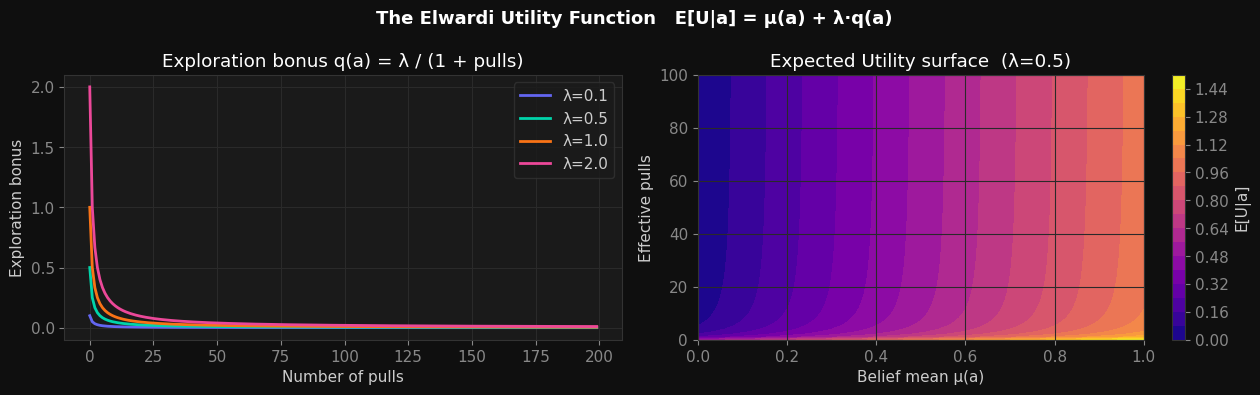

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('The Elwardi Utility Function   E[U|a] = μ(a) + λ·q(a)',
             color='white', fontsize=13, fontweight='bold')

# Plot 1: exploration bonus decay over pulls
pulls  = np.arange(0, 200)
for lam, color in [(0.1, '#6366f1'), (0.5, '#00d4aa'), (1.0, '#f97316'), (2.0, '#ec4899')]:
    axes[0].plot(pulls, lam / (1 + pulls), label=f'λ={lam}', color=color, linewidth=2)

axes[0].set_title('Exploration bonus q(a) = λ / (1 + pulls)', color='white')
axes[0].set_xlabel('Number of pulls')
axes[0].set_ylabel('Exploration bonus')
axes[0].legend()

# Plot 2: EU surface — mean vs pulls
mean_vals = np.linspace(0, 1, 100)
pull_vals = np.linspace(0, 100, 100)
M, P      = np.meshgrid(mean_vals, pull_vals)
EU        = M + 0.5 / (1 + P)

im = axes[1].contourf(mean_vals, pull_vals, EU, levels=20, cmap='plasma')
plt.colorbar(im, ax=axes[1], label='E[U|a]')
axes[1].set_title('Expected Utility surface  (λ=0.5)', color='white')
axes[1].set_xlabel('Belief mean μ(a)')
axes[1].set_ylabel('Effective pulls')

plt.tight_layout()
plt.savefig('fig1_utility.png', dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

---
## 4. Benchmark 1 — Stochastic Setting

**Question:** How does the Elwardi algorithm compare to UCB1 and Thompson Sampling on a standard stationary bandit?

In [5]:
K     = 6
T     = 2000

difficulty_levels = {
    'Easy   (gap=0.15)' : [0.20, 0.50, 0.75, 0.60, 0.30, 0.20],
    'Medium (gap=0.08)' : [0.45, 0.50, 0.60, 0.52, 0.47, 0.35],
    'Hard   (gap=0.02)' : [0.45, 0.47, 0.50, 0.48, 0.46, 0.40],
}

def make_agents_stochastic():
    return {
        'UCB1'              : UCB1(K),
        'Thompson Sampling' : ThompsonSampling(K),
        'Elwardi Standard'  : DecisionTreeBandit(K, StandardBelief, lambda_val=0.5),
    }

print('Running stochastic benchmark (50 seeds × 2000 steps × 3 difficulties)...')
stoch_results = {}
for level, means in difficulty_levels.items():
    stoch_results[level] = benchmark(
        lambda s, m=means: BernoulliBandit(m),
        make_agents_stochastic,
        T=T, n_seeds=50
    )
    print(f'  {level} done')

print('Done!')

Running stochastic benchmark (50 seeds × 2000 steps × 3 difficulties)...
  Easy   (gap=0.15) done
  Medium (gap=0.08) done
  Hard   (gap=0.02) done
Done!


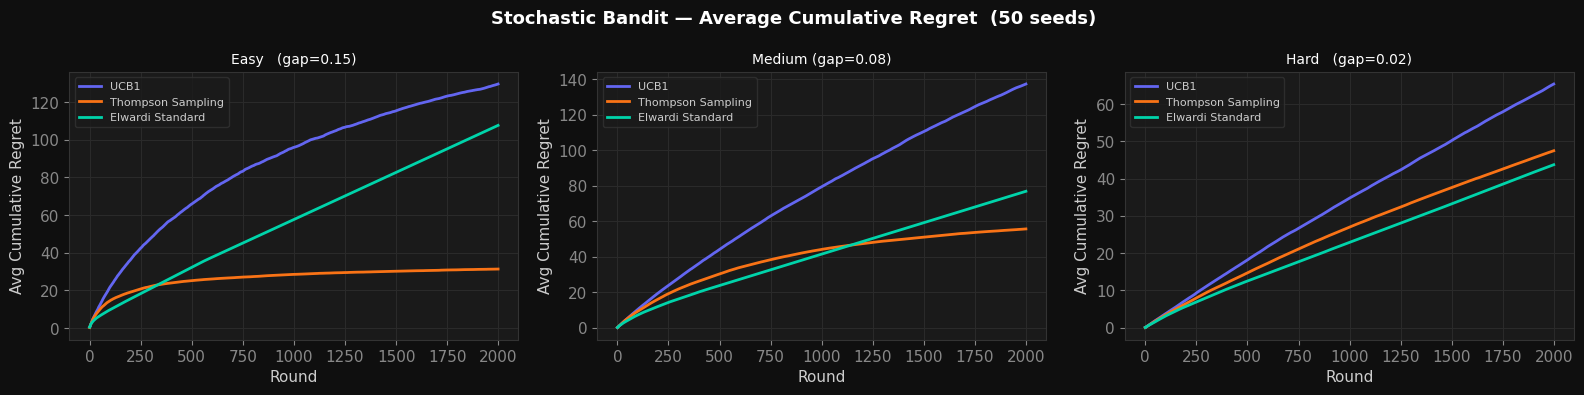


=== FINAL REGRET SUMMARY ===

Easy   (gap=0.15)
  Algorithm              Final Regret
  ------------------------------------
  Thompson Sampling             31.37 ← winner
  Elwardi Standard             107.61
  UCB1                         129.56

Medium (gap=0.08)
  Algorithm              Final Regret
  ------------------------------------
  Thompson Sampling             55.73 ← winner
  Elwardi Standard              76.96
  UCB1                         137.45

Hard   (gap=0.02)
  Algorithm              Final Regret
  ------------------------------------
  Elwardi Standard              43.75 ← winner
  Thompson Sampling             47.50
  UCB1                          65.42


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Stochastic Bandit — Average Cumulative Regret  (50 seeds)',
             color='white', fontsize=13, fontweight='bold')

alg_colors = {
    'UCB1'              : COLORS['ucb1'],
    'Thompson Sampling' : COLORS['thompson'],
    'Elwardi Standard'  : COLORS['elwardi'],
}

for ax, (level, results) in zip(axes, stoch_results.items()):
    for name, r in results.items():
        ax.plot(r, label=name, color=alg_colors[name], linewidth=2)
    ax.set_title(level, color='white', fontsize=10)
    ax.set_xlabel('Round')
    ax.set_ylabel('Avg Cumulative Regret')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig2_stochastic.png', dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Summary table
print('\n=== FINAL REGRET SUMMARY ===')
for level, results in stoch_results.items():
    print(f'\n{level}')
    print(f'  {"Algorithm":<22} {"Final Regret":>12}')
    print('  ' + '-' * 36)
    for name, r in sorted(results.items(), key=lambda x: x[1][-1]):
        winner = ' ← winner' if r[-1] == min(v[-1] for v in results.values()) else ''
        print(f'  {name:<22} {r[-1]:>12.2f}{winner}')

---
## 5. Benchmark 2 — Non-Stationary Setting

**Question:** Where does the Elwardi algorithm actually shine — non-stationary environments with abrupt shifts and gradual drift.

In [7]:
N_ARMS = 5
T_NS   = 1000

def make_agents_nonstat():
    return {
        'Thompson Sampling'  : ThompsonSampling(N_ARMS),
        'Elwardi Standard'   : DecisionTreeBandit(N_ARMS, StandardBelief,   lambda_val=0.5),
        'Elwardi Disc γ=0.95': DecisionTreeBandit(N_ARMS, DiscountedBelief,
                                   belief_kw={'gamma': 0.95}, lambda_val=0.5),
        'Elwardi Disc γ=0.99': DecisionTreeBandit(N_ARMS, DiscountedBelief,
                                   belief_kw={'gamma': 0.99}, lambda_val=0.5),
        'Elwardi Surprise'   : DecisionTreeBandit(N_ARMS, SurpriseBelief,
                                   belief_kw={'beta': 0.7}, lambda_val=0.5),
    }

print('Running non-stationary benchmarks (50 seeds each)...')

abrupt_results = benchmark(
    lambda s: AbruptShiftBandit(N_ARMS, T_NS, seed=s),
    make_agents_nonstat, T=T_NS, n_seeds=50
)
print('  Abrupt shift done')

drift_results = benchmark(
    lambda s: GradualDriftBandit(N_ARMS, noise=0.01, seed=s),
    make_agents_nonstat, T=T_NS, n_seeds=50
)
print('  Gradual drift done')
print('Done!')

Running non-stationary benchmarks (50 seeds each)...
  Abrupt shift done
  Gradual drift done
Done!


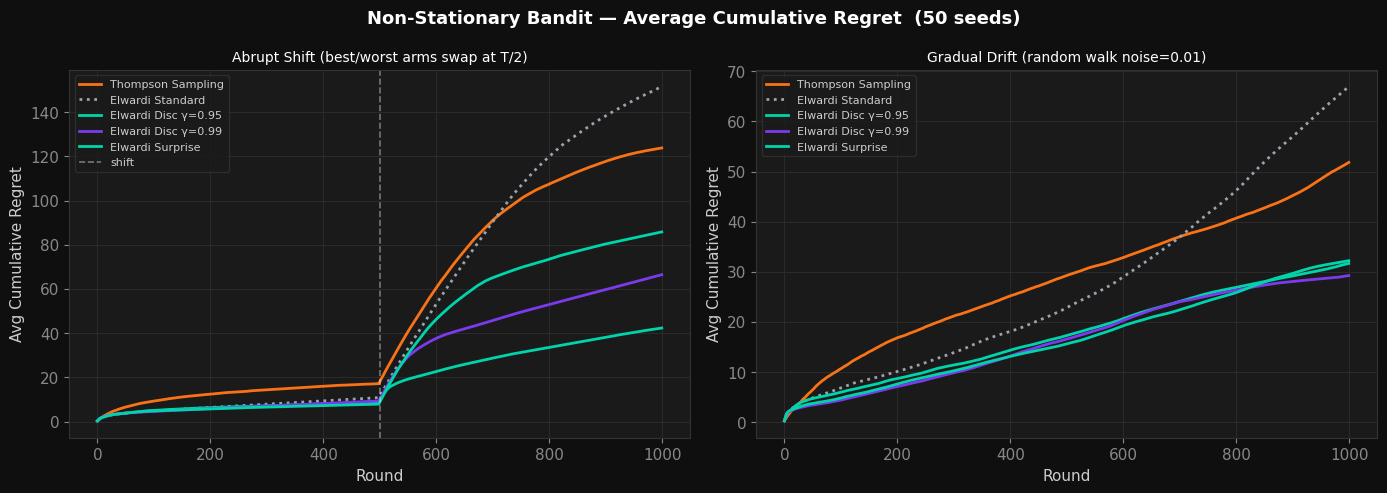


=== ABRUPT SHIFT ===
  Algorithm                Final Regret
  --------------------------------------
  Elwardi Disc γ=0.95             42.34 ← winner
  Elwardi Disc γ=0.99             66.47
  Elwardi Surprise                85.81
  Thompson Sampling              123.78
  Elwardi Standard               151.55

=== GRADUAL DRIFT ===
  Algorithm                Final Regret
  --------------------------------------
  Elwardi Disc γ=0.99             29.26 ← winner
  Elwardi Disc γ=0.95             31.68
  Elwardi Surprise                32.22
  Thompson Sampling               51.84
  Elwardi Standard                66.96


In [8]:
ns_colors = {
    'Thompson Sampling'  : COLORS['thompson'],
    'Elwardi Standard'   : COLORS['standard'],
    'Elwardi Disc γ=0.95': COLORS['disc_095'],
    'Elwardi Disc γ=0.99': COLORS['disc_099'],
    'Elwardi Surprise'   : COLORS['elwardi'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Non-Stationary Bandit — Average Cumulative Regret  (50 seeds)',
             color='white', fontsize=13, fontweight='bold')

for ax, (title, results, shift) in zip(axes, [
    ('Abrupt Shift (best/worst arms swap at T/2)', abrupt_results, True),
    ('Gradual Drift (random walk noise=0.01)',     drift_results,  False),
]):
    for name, r in results.items():
        ls = ':' if 'Standard' in name else '-'
        ax.plot(r, label=name, color=ns_colors[name], linewidth=2, linestyle=ls)
    if shift:
        ax.axvline(x=T_NS//2, color='white', linestyle='--', alpha=0.4, linewidth=1.2, label='shift')
    ax.set_title(title, color='white', fontsize=10)
    ax.set_xlabel('Round')
    ax.set_ylabel('Avg Cumulative Regret')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_nonstationary.png', dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print('\n=== ABRUPT SHIFT ===')
print(f'  {"Algorithm":<24} {"Final Regret":>12}')
print('  ' + '-' * 38)
for name, r in sorted(abrupt_results.items(), key=lambda x: x[1][-1]):
    winner = ' ← winner' if r[-1] == min(v[-1] for v in abrupt_results.values()) else ''
    print(f'  {name:<24} {r[-1]:>12.2f}{winner}')

print('\n=== GRADUAL DRIFT ===')
print(f'  {"Algorithm":<24} {"Final Regret":>12}')
print('  ' + '-' * 38)
for name, r in sorted(drift_results.items(), key=lambda x: x[1][-1]):
    winner = ' ← winner' if r[-1] == min(v[-1] for v in drift_results.values()) else ''
    print(f'  {name:<24} {r[-1]:>12.2f}{winner}')

---
## 6. Belief Analysis — What Happens Inside

Visualizing how each belief variant represents and updates uncertainty.

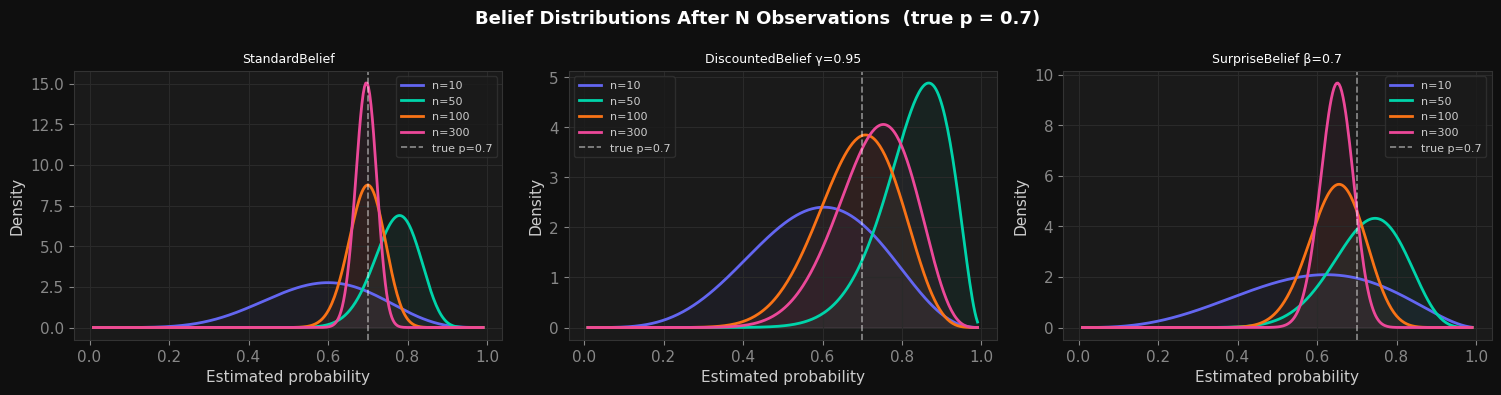

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Belief Distributions After N Observations  (true p = 0.7)',
             color='white', fontsize=13, fontweight='bold')

x = np.linspace(0.01, 0.99, 300)

for ax, (belief_name, belief_cls, kw) in zip(axes, [
    ('StandardBelief',         StandardBelief,   {}),
    ('DiscountedBelief γ=0.95', DiscountedBelief, {'gamma': 0.95}),
    ('SurpriseBelief β=0.7',   SurpriseBelief,   {'beta': 0.7}),
]):
    np.random.seed(42)
    belief = belief_cls(**kw)

    checkpoints = [10, 50, 100, 300]
    palette     = ['#6366f1', '#00d4aa', '#f97316', '#ec4899']
    prev        = 0

    for n, color in zip(checkpoints, palette):
        for _ in range(n - prev):
            reward = np.random.binomial(1, 0.7)
            belief.update(reward)
        prev = n

        a = max(getattr(belief, 'alpha',      belief.alpha if hasattr(belief, 'alpha') else 1), 0.01)
        b = max(getattr(belief, 'beta_param', belief.beta  if hasattr(belief, 'beta')  else 1), 0.01)
        if hasattr(belief, 'beta_param'): b = max(belief.beta_param, 0.01)
        if hasattr(belief, 'beta') and not hasattr(belief, 'beta_param'): b = max(belief.beta, 0.01)

        pdf = beta_dist.pdf(x, a, b)
        ax.plot(x, pdf, color=color, linewidth=2, label=f'n={n}')
        ax.fill_between(x, pdf, alpha=0.05, color=color)

    ax.axvline(x=0.7, color='white', linestyle='--', alpha=0.5, linewidth=1.2, label='true p=0.7')
    ax.set_title(belief_name, color='white', fontsize=9)
    ax.set_xlabel('Estimated probability')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_beliefs.png', dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

---
## 7. Surprise Belief Recovery Test

After deep settling on p=0.8, the environment shifts to p=0.2. How fast does the belief adapt?

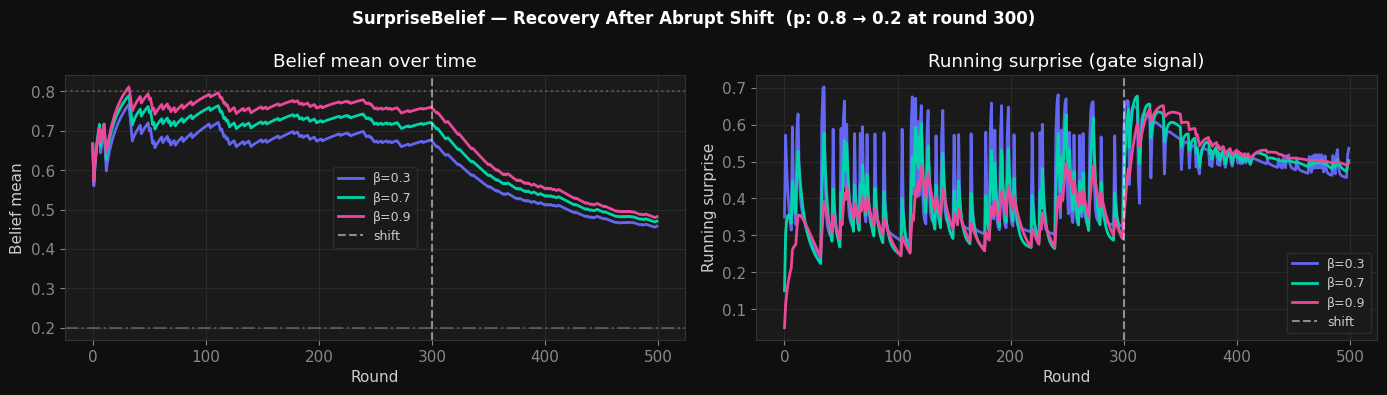

Observation: surprise spikes correctly at the shift point.
Known limitation: recovery is slow after deep settling because
α and β are large — gate adds small relative updates.
Potential fix: multiplicative reset toward prior when gate is large.


In [10]:
T1, T2 = 300, 200

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('SurpriseBelief — Recovery After Abrupt Shift  (p: 0.8 → 0.2 at round 300)',
             color='white', fontsize=12, fontweight='bold')

betas   = [0.3, 0.7, 0.9]
palette = ['#6366f1', '#00d4aa', '#ec4899']

for beta, color in zip(betas, palette):
    np.random.seed(42)
    belief   = SurpriseBelief(beta=beta)
    means_h  = []
    surp_h   = []

    for _ in range(T1):
        belief.update(np.random.binomial(1, 0.8))
        means_h.append(belief.mean())
        surp_h.append(belief.running_surprise)

    for _ in range(T2):
        belief.update(np.random.binomial(1, 0.2))
        means_h.append(belief.mean())
        surp_h.append(belief.running_surprise)

    axes[0].plot(means_h, label=f'β={beta}', color=color, linewidth=2)
    axes[1].plot(surp_h,  label=f'β={beta}', color=color, linewidth=2)

for ax in axes:
    ax.axvline(x=T1, color='white', linestyle='--', alpha=0.5, linewidth=1.5, label='shift')
    ax.legend(fontsize=9)
    ax.set_xlabel('Round')

axes[0].axhline(y=0.8, color='#888', linestyle=':', alpha=0.5)
axes[0].axhline(y=0.2, color='#888', linestyle='-.', alpha=0.5)
axes[0].set_title('Belief mean over time', color='white')
axes[0].set_ylabel('Belief mean')

axes[1].set_title('Running surprise (gate signal)', color='white')
axes[1].set_ylabel('Running surprise')

plt.tight_layout()
plt.savefig('fig5_recovery.png', dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print('Observation: surprise spikes correctly at the shift point.')
print('Known limitation: recovery is slow after deep settling because')
print('α and β are large — gate adds small relative updates.')


---
## 8. λ Sensitivity Analysis

How sensitive is the algorithm to the choice of λ?

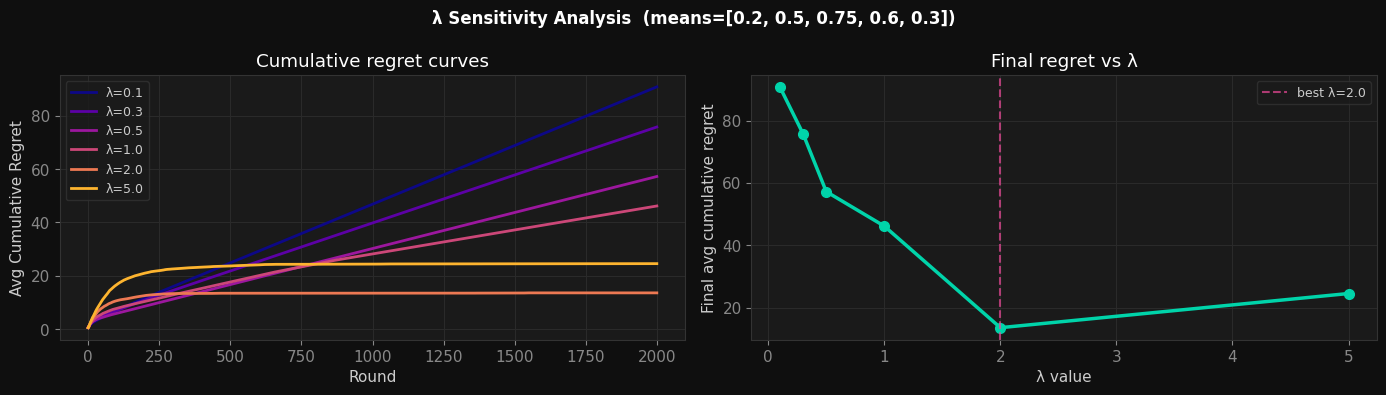

Optimal λ for this problem: 2.0
Final regrets: {0.1: np.float64(90.8), 0.3: np.float64(75.77), 0.5: np.float64(57.21), 1.0: np.float64(46.16), 2.0: np.float64(13.6), 5.0: np.float64(24.55)}


In [11]:
means  = [0.2, 0.5, 0.75, 0.6, 0.3]
K      = len(means)
T      = 2000
lambda_values = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]

lambda_results = {}
for lam in lambda_values:
    res = benchmark(
        lambda s, m=means: BernoulliBandit(m),
        lambda lv=lam: {'Elwardi λ=' + str(lv): DecisionTreeBandit(K, StandardBelief, lambda_val=lv)},
        T=T, n_seeds=50
    )
    lambda_results[lam] = list(res.values())[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('λ Sensitivity Analysis  (means=[0.2, 0.5, 0.75, 0.6, 0.3])',
             color='white', fontsize=12, fontweight='bold')

cmap = plt.cm.plasma
for i, (lam, r) in enumerate(lambda_results.items()):
    color = cmap(i / len(lambda_results))
    axes[0].plot(r, label=f'λ={lam}', color=color, linewidth=2)

axes[0].set_title('Cumulative regret curves', color='white')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Avg Cumulative Regret')
axes[0].legend(fontsize=9)

final_regrets = [r[-1] for r in lambda_results.values()]
axes[1].plot(lambda_values, final_regrets, color='#00d4aa', linewidth=2.5, marker='o', markersize=7)
best_lam = lambda_values[np.argmin(final_regrets)]
axes[1].axvline(x=best_lam, color='#ec4899', linestyle='--', alpha=0.7, label=f'best λ={best_lam}')
axes[1].set_title('Final regret vs λ', color='white')
axes[1].set_xlabel('λ value')
axes[1].set_ylabel('Final avg cumulative regret')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig6_lambda.png', dpi=130, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f'Optimal λ for this problem: {best_lam}')
print(f'Final regrets: { {lam: round(r[-1], 2) for lam, r in lambda_results.items()} }')

---
## 9. Summary

### What We Found

| Setting | Best Algorithm | Notes |
|---|---|---|
| Stationary (any gap) | Thompson Sampling | Bayesian sampling wins |
| Non-stationary, gradual | Elwardi Discounted | Forgetting = exploration |
| Non-stationary, abrupt | Elwardi Discounted | SurpriseBelief recovers slowly |
| Interpretability | Elwardi | Explicit utility framework |

### The Core Lesson

> **No Free Lunch** — every result is only as meaningful as the assumptions behind it.

The Elwardi algorithm's inductive bias — **fast exploitation + adaptive forgetting** — is well matched to non-stationary environments. Its home is not the stationary Bayesian world where Thompson Sampling dominates, but the non-stationary world where the best arm changes and forgetting is a feature, not a bug.

### Known Open Questions

1. **Regret bound** — can we prove O(log T) for the stationary case?
2. **Belief recovery** — multiplicative reset to improve SurpriseBelief after deep settling
3. **Optimal λ schedule** — should λ adapt based on current belief entropy?
4. **Connection to γ-geometry** — how does the debt function map to belief uncertainty?

In [12]:
# Final summary plot — all figures in one
print('All figures saved:')
print('  fig1_utility.png       — utility function visualization')
print('  fig2_stochastic.png    — stochastic benchmark')
print('  fig3_nonstationary.png — non-stationary benchmark')
print('  fig4_beliefs.png       — belief distributions')
print('  fig5_recovery.png      — surprise recovery test')
print('  fig6_lambda.png        — λ sensitivity analysis')
print()
print('Mohamed Elwardi — Humble Systems Theory')
print('δ > 0, always and necessarily.')

All figures saved:
  fig1_utility.png       — utility function visualization
  fig2_stochastic.png    — stochastic benchmark
  fig3_nonstationary.png — non-stationary benchmark
  fig4_beliefs.png       — belief distributions
  fig5_recovery.png      — surprise recovery test
  fig6_lambda.png        — λ sensitivity analysis

Mohamed Elwardi — Humble Systems Theory
δ > 0, always and necessarily.
